# 📚 Notebook 1: PDF Extraction and Exploration

**Project 3: Literary Machine Translation with PDF Document Alignment**

---

## 🎯 Objectives

1. Load bilingual PDFs (EN/FR versions of Tony Attwood's Asperger's Syndrome book)
2. Extract raw text from both documents
3. Identify and isolate chapter boundaries
4. Compare structural alignment between versions
5. Clean and validate extracted text
6. Export chapter-segmented text for alignment pipeline

---

## 📦 Inputs
- `pdf_books/Attwood_Asperger_EN.pdf` (English original)
- `pdf_books/Attwood_Asperger_FR.pdf` (French translation)

## 💾 Outputs
- `data/extracted/chapters_en.json` (English chapters)
- `data/extracted/chapters_fr.json` (French chapters)
- `data/extracted/metadata.json` (structural comparison)

---

**Estimated Runtime:** 5-10 minutes  
**Environment:** VS Code (local)

## 1️⃣ Environment Setup

In [1]:
# Install required libraries (run once)
#!pip install PyMuPDF pdfplumber ftfy langdetect

In [2]:
# Import libraries

import os
import re
import json
from pathlib import Path
from typing import Dict, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# PDF processing
import fitz  # PyMuPDF
import pdfplumber

# Text processing
import ftfy  # Fix text encoding
from langdetect import detect

# Data analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


## 2️⃣ Configure Paths

In [3]:
# Project paths
PROJECT_ROOT = Path.cwd()
PDF_DIR = PROJECT_ROOT / "pdf_books"
OUTPUT_DIR = PROJECT_ROOT / "data" / "extracted"

# PDF files 
EN_PDF = PDF_DIR / "Attwood_Asperger_EN.pdf" 
FR_PDF = PDF_DIR / "Attwood_Asperger_FR.pdf"  

# Verify files exist
print(f"📁 Project root: {PROJECT_ROOT}")
print(f"\n📄 Checking PDF files:")
print(f"   EN: {'✅ Found' if EN_PDF.exists() else '❌ Missing'} - {EN_PDF.name}")
print(f"   FR: {'✅ Found' if FR_PDF.exists() else '❌ Missing'} - {FR_PDF.name}")

if not EN_PDF.exists() or not FR_PDF.exists():
    print("\n⚠️  Please update the PDF filenames above and place PDFs in pdf_books/ folder")
    # List available PDFs
    if PDF_DIR.exists():
        pdfs = list(PDF_DIR.glob("*.pdf"))
        if pdfs:
            print("\n   Available PDFs in folder:")
            for pdf in pdfs:
                print(f"      - {pdf.name}")
else:
    print("\n✅ All files found! Ready to proceed.")

📁 Project root: c:\Users\aheij\Desktop\NLP\NMT with PDF Document Alignment

📄 Checking PDF files:
   EN: ✅ Found - Attwood_Asperger_EN.pdf
   FR: ✅ Found - Attwood_Asperger_FR.pdf

✅ All files found! Ready to proceed.


## 3️⃣ PDF Text Extraction Functions

In [4]:
# PDF Extraction Functions

def extract_text_pymupdf(pdf_path: Path) -> Dict[int, str]:
    """
    Extract text from PDF using PyMuPDF (fast, good for clean PDFs).
    
    Returns:
        Dict mapping page_number -> text_content
    """
    doc = fitz.open(pdf_path)
    pages = {}
    
    for page_num in range(len(doc)):
        page = doc[page_num]
        text = page.get_text("text")
        # Clean text: fix encoding, normalize whitespace
        text = ftfy.fix_text(text)
        text = re.sub(r'\n+', '\n', text)  # Remove excessive newlines
        text = re.sub(r' +', ' ', text)     # Normalize spaces
        pages[page_num + 1] = text.strip()
    
    doc.close()
    return pages


def get_pdf_info(pdf_path: Path) -> Dict:
    """
    Extract metadata from PDF.
    """
    doc = fitz.open(pdf_path)
    info = {
        'filename': pdf_path.name,
        'pages': len(doc),
        'metadata': doc.metadata,
    }
    doc.close()
    return info


print("✅ PDF extraction functions defined")

✅ PDF extraction functions defined


## 4️⃣ Extract Text from Both PDFs

In [5]:
# Extract English PDF
print("📖 Extracting English PDF...")
en_pages = extract_text_pymupdf(EN_PDF)
en_info = get_pdf_info(EN_PDF)
print(f"   ✅ Extracted {len(en_pages)} pages")

# Extract French PDF
print("\n📖 Extracting French PDF...")
fr_pages = extract_text_pymupdf(FR_PDF)
fr_info = get_pdf_info(FR_PDF)
print(f"   ✅ Extracted {len(fr_pages)} pages")

# Quick comparison
print(f"\n📊 Quick Stats:")
print(f"   EN Pages: {en_info['pages']}")
print(f"   FR Pages: {fr_info['pages']}")
print(f"   Page difference: {abs(en_info['pages'] - fr_info['pages'])} pages")

📖 Extracting English PDF...
   ✅ Extracted 401 pages

📖 Extracting French PDF...
   ✅ Extracted 508 pages

📊 Quick Stats:
   EN Pages: 401
   FR Pages: 508
   Page difference: 107 pages


## 5️⃣ Inspect Sample Pages

In [6]:
# Show first few pages to identify structure
print("🔍 ENGLISH - First 3 pages preview:\n")
for page_num in range(1, min(4, len(en_pages) + 1)):
    text = en_pages[page_num][:300]  # First 300 chars
    print(f"--- Page {page_num} ---")
    print(text)
    print("\n")

print("\n" + "="*80 + "\n")

print("🔍 FRENCH - First 3 pages preview:\n")
for page_num in range(1, min(4, len(fr_pages) + 1)):
    text = fr_pages[page_num][:300]
    print(f"--- Page {page_num} ---")
    print(text)
    print("\n")

🔍 ENGLISH - First 3 pages preview:

--- Page 1 ---



--- Page 2 ---



--- Page 3 ---
'Tony Attwood explores in depth the complexity of the mysterious group of clinical pictures known
collectively as Asperger's syndrome, part of the wider autistic spectrum. He describes all the puzzling
and fascinating aspects of these conditions and brings them vividly to life with illustrations fro




🔍 FRENCH - First 3 pages preview:

--- Page 1 ---
Tony Attwood 
Traduction de Josef Schovanec
Révision scientifique d'Elaine Hardiman-Taveau 
et Cécile Veasna Malterre
Le syndrome 
d'Asperger
Guide complet
3e édition
Questions de personne
TED


--- Page 2 ---
Le syndrome 
d'Asperger


--- Page 3 ---
Collection dirigée par
Ghislain Magerotte, Professeur à la Faculté de 
Psychologie et des Sciences de l'éducation de l'Université de Mons (Belgique)
Les ouvrages de cette série sont plus particulièrement consacrés aux troubles envahissants du 
développement, qui se caractérisent par des altérations 




## 6️⃣ Identify Chapter Boundaries

**Strategy:** Look for chapter markers like "Chapter 1", "Chapitre 1", or numeric patterns.
You may need to adjust these patterns based on your actual PDF structure.

In [7]:
# Chapter Detection Function
def find_chapters(pages: Dict[int, str], lang: str = 'en') -> Dict[str, Dict]:
    """
    Identify chapter boundaries in extracted pages.
    
    Args:
        pages: Dict of page_num -> text
        lang: 'en' or 'fr'
    
    Returns:
        Dict mapping chapter_id -> {title, start_page, end_page, text}
    """
    # Chapter patterns (adjust these based on your PDF!)
    if lang == 'en':
        chapter_patterns = [
            r'^\s*Chapter\s+(\d+)',
            r'^\s*CHAPTER\s+(\d+)',
            r'^\s*(\d+)\.\s+[A-Z]',  # "1. TITLE"
        ]
    else:  # French
        chapter_patterns = [
            r'^\s*Chapitre\s+(\d+)',
            r'^\s*CHAPITRE\s+(\d+)',
            r'^\s*(\d+)\.\s+[A-Z]',
        ]
    
    chapters = {}
    current_chapter = None
    chapter_text = []
    
    for page_num, text in sorted(pages.items()):
        lines = text.split('\n')
        
        for line in lines:
            # Check if this line is a chapter heading
            for pattern in chapter_patterns:
                match = re.match(pattern, line, re.MULTILINE)
                if match:
                    # Save previous chapter
                    if current_chapter:
                        chapters[current_chapter]['text'] = '\n'.join(chapter_text)
                        chapters[current_chapter]['end_page'] = page_num - 1
                    
                    # Start new chapter
                    chapter_num = match.group(1)
                    chapter_id = f"chapter_{chapter_num}"
                    current_chapter = chapter_id
                    chapter_text = []
                    
                    chapters[chapter_id] = {
                        'number': int(chapter_num),
                        'title': line.strip(),
                        'start_page': page_num,
                        'end_page': None,
                    }
                    break
        
        # Add page text to current chapter
        if current_chapter:
            chapter_text.append(text)
    
    # Close last chapter
    if current_chapter:
        chapters[current_chapter]['text'] = '\n'.join(chapter_text)
        chapters[current_chapter]['end_page'] = max(pages.keys())
    
    return chapters


print("✅ Chapter detection function defined")
print("\n⚠️  Note: You may need to adjust chapter patterns after inspecting your PDFs!")

✅ Chapter detection function defined

⚠️  Note: You may need to adjust chapter patterns after inspecting your PDFs!


In [8]:
# Detect chapters
print("🔍 Detecting chapters in English PDF...")
en_chapters = find_chapters(en_pages, lang='en')
print(f"   ✅ Found {len(en_chapters)} chapters")

print("\n🔍 Detecting chapters in French PDF...")
fr_chapters = find_chapters(fr_pages, lang='fr')
print(f"   ✅ Found {len(fr_chapters)} chapters")

# Display chapter overview
print("\n" + "="*80)
print("📚 CHAPTER OVERVIEW")
print("="*80)

if en_chapters:
    print("\nEnglish Chapters:")
    for ch_id, ch_data in sorted(en_chapters.items(), key=lambda x: x[1]['number']):
        print(f"   {ch_data['number']:2d}. {ch_data['title'][:60]:<60} (pp. {ch_data['start_page']}-{ch_data['end_page']})")
else:
    print("\n⚠️  No chapters detected in English PDF. Check patterns!")

if fr_chapters:
    print("\nFrench Chapters:")
    for ch_id, ch_data in sorted(fr_chapters.items(), key=lambda x: x[1]['number']):
        print(f"   {ch_data['number']:2d}. {ch_data['title'][:60]:<60} (pp. {ch_data['start_page']}-{ch_data['end_page']})")
else:
    print("\n⚠️  No chapters detected in French PDF. Check patterns!")

print(f"\n{'✅' if len(en_chapters) == len(fr_chapters) else '⚠️'} Chapter count match: EN={len(en_chapters)}, FR={len(fr_chapters)}")

🔍 Detecting chapters in English PDF...
   ✅ Found 10 chapters

🔍 Detecting chapters in French PDF...
   ✅ Found 17 chapters

📚 CHAPTER OVERVIEW

English Chapters:
    1. 1. WHAT CAUSES ASPERGER'S SYNDROME?                          (pp. 331-333)
    2. 2. SHOULD YOU EXPLAIN THE DIAGNOSIS TO THE CHILD?            (pp. 334-333)
    3. 3. WHEN AND HOW DO YOU EXPLAIN THE DIAGNOSIS?                (pp. 334-337)
    4. Chapter 4, on teasing and bullying, describes how a child wi (pp. 339-344)
    5. 5. CAN ASPERGER'S SYNDROME BE CONFUSED WITH                  (pp. 345-346)
    6. 6. WHAT ARE THE LONG-TERM OUTCOMES?                          (pp. 347-348)
    7. 7. WHAT HAPPENED TO JACK?                                    (pp. 349-401)
    8. 8. Language                                                  (pp. 11-10)
    9. Chapter 9) in terms of their ability to decode print, but th (pp. 227-330)
   10. Chapter 10). Complex whole-body movements may also be associ (pp. 178-226)

French Chapters:
 

## 6️⃣.5️⃣ Create Manual Chapter Mapping

**Since automatic detection found inconsistent results (EN=10, FR=17, actual=15), let's manually map chapters.**

**Instructions:**
1. Open both PDFs side by side
2. For each of the 15 chapters, note down:
   - Chapter title in English
   - Starting page number in EN PDF
   - Ending page number in EN PDF (look for next chapter start - 1)
   - Chapter title in French
   - Starting page number in FR PDF
   - Ending page number in FR PDF
3. Fill in the dictionary below

In [9]:
# MANUAL CHAPTER MAPPING
# Fill in the page numbers for all 15 chapters by inspecting both PDFs

MANUAL_CHAPTER_MAPPING = {
    1: {
        'en': {'title': 'What is Asperger’s Syndrome?', 'start_page': 15, 'end_page': 38},
        'fr': {'title': 'Qu’est-ce que le Syndrome d’Asperger ?', 'start_page': 16, 'end_page': 45}
    },
    2: {
        'en': {'title': 'The Diagnosis', 'start_page': 39, 'end_page': 58},
        'fr': {'title': 'Le diagnostic', 'start_page': 46, 'end_page': 68}
    },
    3: {
        'en': {'title': 'Social Understanding and Friendship', 'start_page': 59, 'end_page': 98},
        'fr': {'title': 'Compréhension sociale et amitié', 'start_page': 70, 'end_page': 117}
    },
    4: {
        'en': {'title': 'Teasing and Bullying', 'start_page': 99, 'end_page': 115},
        'fr': {'title': 'Harcèlement moral et maltraitance', 'start_page': 118, 'end_page': 138}
    },
    5: {
        'en': {'title': 'Theory of Mind', 'start_page': 116, 'end_page': 131},
        'fr': {'title': 'Théorie de l’Esprit (Theory of Mind – ToM)', 'start_page': 140, 'end_page': 158}
    },
    6: {
        'en': {'title': 'The Understanding and Expression of Emotions', 'start_page': 132, 'end_page': 175},
        'fr': {'title': 'Comprendre et exprimer les émotions', 'start_page': 160, 'end_page': 212}
    },
    7: {
        'en': {'title': 'Special Interests', 'start_page': 176, 'end_page': 205},
        'fr': {'title': 'Les intérêts spécifiques', 'start_page': 214, 'end_page': 250}
    },
    8: {
        'en': {'title': 'Language', 'start_page': 206, 'end_page': 231},
        'fr': {'title': 'Le langage ', 'start_page': 252, 'end_page': 282}
    },
    9: {
        'en': {'title': 'Cognitive Abilities', 'start_page': 232, 'end_page': 262},
        'fr': {'title': 'Aptitudes intellectuelles', 'start_page': 284, 'end_page': 321}
    },
    10: {
        'en': {'title': 'Movement and Coordination', 'start_page': 263, 'end_page': 274},
        'fr': {'title': 'Les mouvements et leur coordination', 'start_page': 322, 'end_page': 336}
    },
    11: {
        'en': {'title': 'Sensory Sensitivity', 'start_page': 275, 'end_page': 295},
        'fr': {'title': 'Sensibilité sensorielle', 'start_page': 338, 'end_page': 363}
    },
    12: {
        'en': {'title': 'Life After School: College and Career', 'start_page': 296, 'end_page': 307},
        'fr': {'title': 'La vie après l’école : université et carrière', 'start_page': 364, 'end_page': 377}
    },
    13: {
        'en': {'title': 'Long-term Relationships', 'start_page': 308, 'end_page': 319},
        'fr': {'title': 'Relations de longue durée', 'start_page': 378, 'end_page': 391}
    },
    14: {
        'en': {'title': 'Psychotherapy', 'start_page': 320, 'end_page': 330},
        'fr': {'title': 'Les psychothérapies ', 'start_page': 392, 'end_page': 405}
    },
    15: {
        'en': {'title': 'Frequently Asked Questions', 'start_page': 331, 'end_page': 351},
        'fr': {'title': 'Questions fréquemment posées ', 'start_page': 406, 'end_page': 430}
    }
}

print("📝 Manual chapter mapping template created")
print("⚠️  Please fill in the page numbers and titles by inspecting your PDFs!")
print("\n💡 Tip: Use Adobe Reader or any PDF viewer that shows page numbers")

📝 Manual chapter mapping template created
⚠️  Please fill in the page numbers and titles by inspecting your PDFs!

💡 Tip: Use Adobe Reader or any PDF viewer that shows page numbers


In [10]:
# HELPER FUNCTION: Extract chapters based on manual mapping
def extract_chapters_from_mapping(pages: Dict[int, str], mapping: Dict, lang: str) -> Dict[str, Dict]:
    """
    Extract chapters using manual page number mapping.
    
    Args:
        pages: Dict of page_num -> text
        mapping: MANUAL_CHAPTER_MAPPING dictionary
        lang: 'en' or 'fr'
    
    Returns:
        Dict mapping chapter_id -> {number, title, start_page, end_page, text}
    """
    chapters = {}
    
    for chapter_num, chapter_info in mapping.items():
        lang_info = chapter_info[lang]
        start_page = lang_info['start_page']
        end_page = lang_info['end_page']
        
        # Skip if pages are not filled in (still 0)
        if start_page == 0 or end_page == 0:
            continue
        
        # Extract text from specified page range
        chapter_text = []
        for page_num in range(start_page, end_page + 1):
            if page_num in pages:
                chapter_text.append(pages[page_num])
        
        chapter_id = f"chapter_{chapter_num}"
        chapters[chapter_id] = {
            'number': chapter_num,
            'title': lang_info['title'],
            'start_page': start_page,
            'end_page': end_page,
            'text': '\\n'.join(chapter_text)
        }
    
    return chapters


# APPLY MANUAL MAPPING (run this after filling in the mapping above)
def apply_manual_mapping():
    """Apply the manual chapter mapping to extract chapters."""
    global en_chapters, fr_chapters
    
    # Check if mapping is filled in
    first_chapter = MANUAL_CHAPTER_MAPPING[1]
    if first_chapter['en']['start_page'] == 0 or first_chapter['fr']['start_page'] == 0:
        print("⚠️  Manual mapping not filled in yet!")
        print("   Please update MANUAL_CHAPTER_MAPPING with actual page numbers first.")
        return False
    
    print("🔧 Applying manual chapter mapping...")
    en_chapters = extract_chapters_from_mapping(en_pages, MANUAL_CHAPTER_MAPPING, 'en')
    fr_chapters = extract_chapters_from_mapping(fr_pages, MANUAL_CHAPTER_MAPPING, 'fr')
    
    print(f"   ✅ Extracted {len(en_chapters)} EN chapters")
    print(f"   ✅ Extracted {len(fr_chapters)} FR chapters")
    
    if len(en_chapters) == len(fr_chapters) == 15:
        print("   ✅ Perfect alignment: Both have 15 chapters!")
        return True
    else:
        print(f"   ⚠️  Chapter count mismatch: EN={len(en_chapters)}, FR={len(fr_chapters)}")
        return False

# Uncomment the line below AFTER filling in the manual mapping

apply_manual_mapping()

print("✅ Helper functions defined")
print("\\n📋 Next steps:")
print("   1. Fill in MANUAL_CHAPTER_MAPPING above with actual page numbers")
print("   2. Uncomment and run: apply_manual_mapping()")
print("   3. Continue with the rest of the notebook")

🔧 Applying manual chapter mapping...
   ✅ Extracted 15 EN chapters
   ✅ Extracted 15 FR chapters
   ✅ Perfect alignment: Both have 15 chapters!
✅ Helper functions defined
\n📋 Next steps:
   1. Fill in MANUAL_CHAPTER_MAPPING above with actual page numbers
   2. Uncomment and run: apply_manual_mapping()
   3. Continue with the rest of the notebook


## 6️⃣.6️⃣ Quick Page Inspector (Helper Tool)

**Use this to quickly check what's on specific pages to identify chapter boundaries:**

In [11]:
# QUICK PAGE INSPECTOR - helps you find chapter boundaries
def inspect_page(page_num: int, lang: str = 'en', chars: int = 500):
    """
    Show the first N characters of a specific page.
    Useful for finding chapter starts.
    """
    pages = en_pages if lang == 'en' else fr_pages
    
    if page_num not in pages:
        print(f"❌ Page {page_num} not found in {lang.upper()} PDF")
        return
    
    text = pages[page_num]
    print(f"{'='*80}")
    print(f"📄 {lang.upper()} PDF - Page {page_num}")
    print(f"{'='*80}")
    print(text[:chars])
    if len(text) > chars:
        print(f"\n... ({len(text) - chars} more characters)")
    print(f"{'='*80}\n")


def inspect_page_range(start: int, end: int, lang: str = 'en', chars: int = 200):
    """
    Show first N chars from a range of pages (useful for finding chapter boundaries).
    """
    pages = en_pages if lang == 'en' else fr_pages
    
    print(f"\n🔍 Inspecting {lang.upper()} pages {start}-{end}:\n")
    for page_num in range(start, end + 1):
        if page_num in pages:
            text = pages[page_num][:chars]
            # Check if this looks like a chapter start
            has_chapter = bool(re.search(r'(chapter|chapitre)\s+\d+', text, re.IGNORECASE))
            marker = "📌 POSSIBLE CHAPTER START" if has_chapter else ""
            
            print(f"Page {page_num:3d}: {text[:80]}... {marker}")
        else:
            print(f"Page {page_num:3d}: [NOT FOUND]")
    print()


# EXAMPLE USAGE:
# inspect_page(50, lang='en', chars=500)  # View page 50 of EN PDF
# inspect_page(55, lang='fr', chars=500)  # View page 55 of FR PDF
# inspect_page_range(40, 60, lang='en')   # Scan EN pages 40-60 for chapter markers

print("✅ Page inspector tools ready!")
print("\n💡 Example usage:")
print("   inspect_page(50, lang='en')          # View full page 50 (EN)")
print("   inspect_page_range(40, 60, 'fr')     # Scan FR pages 40-60")
print("   inspect_page_range(1, 30, 'en', 100) # Scan EN pages 1-30, show 100 chars")

✅ Page inspector tools ready!

💡 Example usage:
   inspect_page(50, lang='en')          # View full page 50 (EN)
   inspect_page_range(40, 60, 'fr')     # Scan FR pages 40-60
   inspect_page_range(1, 30, 'en', 100) # Scan EN pages 1-30, show 100 chars


## 6️⃣.7️⃣ Verify Page Number Mapping

**Important:** Make sure your page numbers match the PDF's actual page count, not the printed page numbers!

For example, if the French PDF has:
- Pages I-X (Roman numerals) = PDF pages 1-10
- Chapter 1 shows "page 1" but is actually PDF page 11

Then you should use `'start_page': 11` in your mapping, not `'start_page': 1`

In [12]:
# VERIFY YOUR MAPPING - Check if the page numbers are correct
def verify_mapping():
    """
    Verify that the manual mapping page numbers actually contain chapter content.
    """
    print("🔍 VERIFYING MANUAL CHAPTER MAPPING\n")
    print("="*80)
    
    # Check first 3 chapters for both languages
    for chapter_num in [1, 2, 3]:
        if chapter_num not in MANUAL_CHAPTER_MAPPING:
            continue
            
        chapter_info = MANUAL_CHAPTER_MAPPING[chapter_num]
        
        # Check English
        en_start = chapter_info['en']['start_page']
        en_title = chapter_info['en']['title']
        
        print(f"\n📘 Chapter {chapter_num} (EN): {en_title}")
        print(f"   Mapped to page {en_start}")
        
        if en_start in en_pages:
            preview = en_pages[en_start][:200]
            print(f"   Preview: {preview[:100]}...")
            # Check if title appears in the page
            if any(word.lower() in preview.lower() for word in en_title.split()[:3]):
                print("   ✅ Title keywords found on page")
            else:
                print("   ⚠️  Title keywords NOT found - check page number!")
        else:
            print(f"   ❌ Page {en_start} doesn't exist in EN PDF!")
        
        # Check French
        fr_start = chapter_info['fr']['start_page']
        fr_title = chapter_info['fr']['title']
        
        print(f"\n📗 Chapter {chapter_num} (FR): {fr_title}")
        print(f"   Mapped to page {fr_start}")
        
        if fr_start in fr_pages:
            preview = fr_pages[fr_start][:200]
            print(f"   Preview: {preview[:100]}...")
            # Check if title appears in the page
            if any(word.lower() in preview.lower() for word in fr_title.split()[:3]):
                print("   ✅ Title keywords found on page")
            else:
                print("   ⚠️  Title keywords NOT found - check page number!")
        else:
            print(f"   ❌ Page {fr_start} doesn't exist in FR PDF!")
        
        print("-"*80)
    
    print("\n💡 If you see ⚠️ or ❌ warnings:")
    print("   1. The printed page number might differ from PDF page count")
    print("   2. Use inspect_page() to find the correct PDF page number")
    print("   3. Update MANUAL_CHAPTER_MAPPING and re-run apply_manual_mapping()")

# Run verification
verify_mapping()

🔍 VERIFYING MANUAL CHAPTER MAPPING


📘 Chapter 1 (EN): What is Asperger’s Syndrome?
   Mapped to page 15
   Preview: chapter 1
What is Asperger's Syndrome?
Not everything that steps out of line, and thus 'abnormal', m...
   ✅ Title keywords found on page

📗 Chapter 1 (FR): Qu’est-ce que le Syndrome d’Asperger ?
   Mapped to page 16
   Preview: 1
Chapitre 1
Qu'est-ce que 
le Syndrome d'Asperger ?
Tout ce qui sort de la norme, et donc considéré...
   ✅ Title keywords found on page
--------------------------------------------------------------------------------

📘 Chapter 2 (EN): The Diagnosis
   Mapped to page 39
   Preview: chapter 2
The Diagnosis
One can spot such children instantly. They are recognizable from
small detai...
   ✅ Title keywords found on page

📗 Chapter 2 (FR): Le diagnostic
   Mapped to page 46
   Preview: 31
Chapitre 2
Le diagnostic
On peut repérer instantanément ces enfants. On les reconnaît à de 
petit...
   ✅ Title keywords found on page
---------------------------

## 7️⃣ Chapter Statistics and Validation

In [15]:
# CHAPTER STATISTICS AND COMPARISON
def chapter_stats(chapters: Dict, lang: str) -> pd.DataFrame:
    """
    Calculate statistics for extracted chapters.
    """
    stats = []
    for ch_id, ch_data in sorted(chapters.items(), key=lambda x: x[1]['number']):
        text = ch_data.get('text', '')
        stats.append({
            'Chapter': ch_data['number'],
            'Title': ch_data['title'][:40],
            'Pages': f"{ch_data['start_page']}-{ch_data['end_page']}",
            'Chars': len(text),
            'Words': len(text.split()),
            'Lines': text.count('\n'),
            'Language': lang
        })
    return pd.DataFrame(stats)


if en_chapters and fr_chapters:
    en_stats = chapter_stats(en_chapters, 'EN')
    fr_stats = chapter_stats(fr_chapters, 'FR')
    
    print("📊 ENGLISH CHAPTERS")
    print(en_stats.to_string(index=False))
    
    print("\n📊 FRENCH CHAPTERS")
    print(fr_stats.to_string(index=False))
    
    # Compare word counts
    print("\n" + "="*80)
    print("📈 COMPARISON")
    print("="*80)
    print(f"Total EN words: {en_stats['Words'].sum():,}")
    print(f"Total FR words: {fr_stats['Words'].sum():,}")
    print(f"FR/EN ratio: {fr_stats['Words'].sum() / en_stats['Words'].sum():.2f}")
    print("\n💡 French translations typically have 10-15% more words than English")
else:
    print("⚠️  Chapters not detected. Use manual definition above.")

📊 ENGLISH CHAPTERS
 Chapter                                    Title   Pages  Chars  Words  Lines Language
       1             What is Asperger’s Syndrome?   15-38  70031  11212   1002       EN
       2                            The Diagnosis   39-58  55185   8497    822       EN
       3      Social Understanding and Friendship   59-98 118208  19190   1649       EN
       4                     Teasing and Bullying  99-115  48545   8082    675       EN
       5                           Theory of Mind 116-131  45114   7335    640       EN
       6 The Understanding and Expression of Emot 132-175 132971  21438   1783       EN
       7                        Special Interests 176-205  88660  14433   1237       EN
       8                                 Language 206-231  75575  12305   1102       EN
       9                      Cognitive Abilities 232-262  91560  14599   1304       EN
      10                Movement and Coordination 263-274  34438   5525    502       EN
      11     

## 8️⃣ Visualize Chapter Lengths

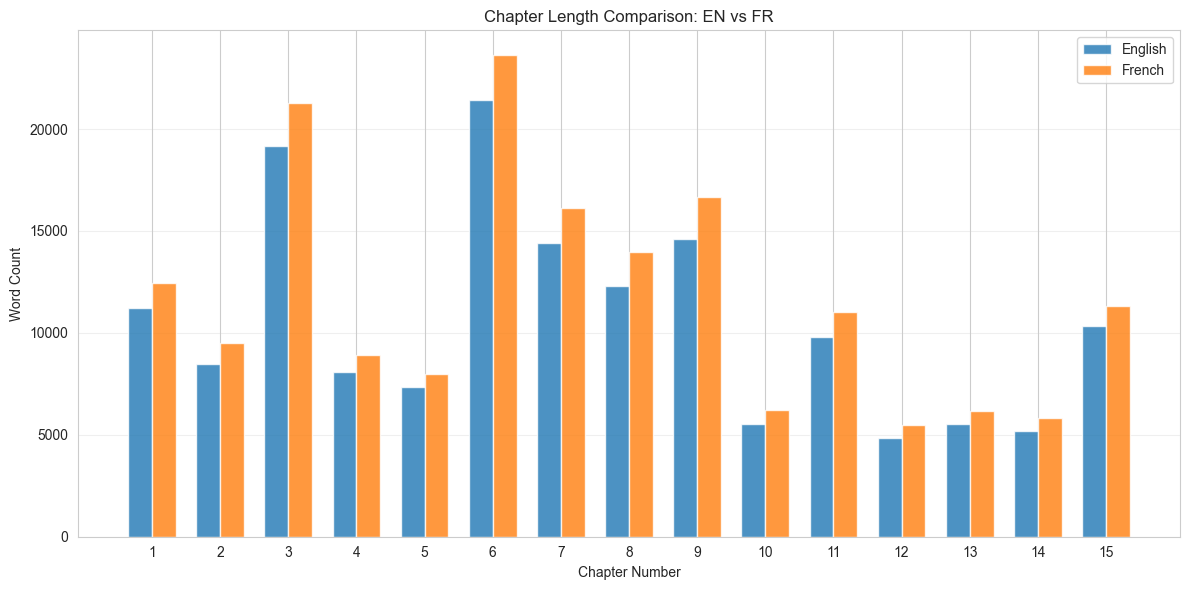

✅ Chapters with similar lengths are likely well-aligned


In [14]:
if en_chapters and fr_chapters:
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    chapters_num = en_stats['Chapter'].values
    en_words = en_stats['Words'].values
    fr_words = fr_stats['Words'].values
    
    x = range(len(chapters_num))
    width = 0.35
    
    ax.bar([i - width/2 for i in x], en_words, width, label='English', alpha=0.8)
    ax.bar([i + width/2 for i in x], fr_words, width, label='French', alpha=0.8)
    
    ax.set_xlabel('Chapter Number')
    ax.set_ylabel('Word Count')
    ax.set_title('Chapter Length Comparison: EN vs FR')
    ax.set_xticks(x)
    ax.set_xticklabels(chapters_num)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("✅ Chapters with similar lengths are likely well-aligned")
else:
    print("⚠️  No chapter data to visualize")

## 9️⃣ Clean and Normalize Text

In [16]:
def clean_chapter_text(text: str) -> str:
    """
    Clean extracted chapter text:
    - Remove page numbers
    - Remove headers/footers
    - Normalize whitespace
    - Fix encoding issues
    """
    # Fix encoding
    text = ftfy.fix_text(text)
    
    # Remove page numbers (common patterns)
    text = re.sub(r'^\s*\d+\s*$', '', text, flags=re.MULTILINE)
    text = re.sub(r'^\s*-\s*\d+\s*-\s*$', '', text, flags=re.MULTILINE)
    
    # Remove running headers/footers (book title, chapter title)
    # Adjust these patterns based on your PDF!
    text = re.sub(r'^\s*The Complete Guide to Asperger.*$', '', text, flags=re.MULTILINE | re.IGNORECASE)
    text = re.sub(r'^\s*Le syndrome d\'Asperger.*$', '', text, flags=re.MULTILINE | re.IGNORECASE)
    
    # Normalize whitespace
    text = re.sub(r' +', ' ', text)        # Multiple spaces -> single space
    text = re.sub(r'\n{3,}', '\n\n', text) # Multiple newlines -> double newline
    
    # Remove hyphenation at line breaks
    text = re.sub(r'(\w+)-\n(\w+)', r'\1\2', text)
    
    return text.strip()


# Apply cleaning
if en_chapters and fr_chapters:
    print("🧹 Cleaning chapter text...")
    for ch_id in en_chapters:
        en_chapters[ch_id]['text'] = clean_chapter_text(en_chapters[ch_id]['text'])
    for ch_id in fr_chapters:
        fr_chapters[ch_id]['text'] = clean_chapter_text(fr_chapters[ch_id]['text'])
    print("   ✅ Text cleaning complete")
else:
    print("⚠️  No chapters to clean")

🧹 Cleaning chapter text...
   ✅ Text cleaning complete


## 🔟 Export Chapters to JSON

In [17]:
# SAVE EXTRACTED CHAPTERS AND METADATA
if en_chapters and fr_chapters:
    # Save English chapters
    en_output = OUTPUT_DIR / "chapters_en.json"
    with open(en_output, 'w', encoding='utf-8') as f:
        json.dump(en_chapters, f, ensure_ascii=False, indent=2)
    print(f"✅ Saved English chapters: {en_output}")
    
    # Save French chapters
    fr_output = OUTPUT_DIR / "chapters_fr.json"
    with open(fr_output, 'w', encoding='utf-8') as f:
        json.dump(fr_chapters, f, ensure_ascii=False, indent=2)
    print(f"✅ Saved French chapters: {fr_output}")
    
    # Save metadata
    metadata = {
        'english': {
            'filename': EN_PDF.name,
            'total_pages': en_info['pages'],
            'total_chapters': len(en_chapters),
            'total_words': sum(len(ch['text'].split()) for ch in en_chapters.values())
        },
        'french': {
            'filename': FR_PDF.name,
            'total_pages': fr_info['pages'],
            'total_chapters': len(fr_chapters),
            'total_words': sum(len(ch['text'].split()) for ch in fr_chapters.values())
        },
        'alignment_status': 'ready' if len(en_chapters) == len(fr_chapters) else 'needs_review'
    }
    
    metadata_output = OUTPUT_DIR / "metadata.json"
    with open(metadata_output, 'w', encoding='utf-8') as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)
    print(f"✅ Saved metadata: {metadata_output}")
    
    print("\n" + "="*80)
    print("🎉 EXTRACTION COMPLETE!")
    print("="*80)
    print(f"✅ Extracted {len(en_chapters)} EN chapters ({metadata['english']['total_words']:,} words)")
    print(f"✅ Extracted {len(fr_chapters)} FR chapters ({metadata['french']['total_words']:,} words)")
    print(f"\n📂 Output files saved in: {OUTPUT_DIR}")
    print("\n➡️  Next step: Open Notebook 2 (02_text_alignment_and_corpus_building.ipynb)")
else:
    print("⚠️  Chapter extraction incomplete. Please review and fix chapter detection.")

✅ Saved English chapters: c:\Users\aheij\Desktop\NLP\NMT with PDF Document Alignment\data\extracted\chapters_en.json
✅ Saved French chapters: c:\Users\aheij\Desktop\NLP\NMT with PDF Document Alignment\data\extracted\chapters_fr.json
✅ Saved metadata: c:\Users\aheij\Desktop\NLP\NMT with PDF Document Alignment\data\extracted\metadata.json

🎉 EXTRACTION COMPLETE!
✅ Extracted 15 EN chapters (154,592 words)
✅ Extracted 15 FR chapters (174,986 words)

📂 Output files saved in: c:\Users\aheij\Desktop\NLP\NMT with PDF Document Alignment\data\extracted

➡️  Next step: Open Notebook 2 (02_text_alignment_and_corpus_building.ipynb)


---

## 📋 Summary

**Completed Tasks:**
- ✅ Loaded bilingual PDFs
- ✅ Extracted text from all pages
- ✅ Identified chapter boundaries
- ✅ Cleaned and normalized text
- ✅ Exported chapter-segmented data

**Outputs:**
- `data/extracted/chapters_en.json`
- `data/extracted/chapters_fr.json`
- `data/extracted/metadata.json`

**Next Steps:**
1. Open `02_text_alignment_and_corpus_building.ipynb`
2. Perform sentence-level alignment
3. Build parallel corpus for training

---